# AfriMarket — Analyse Strategique des Donnees
### Juillet – Decembre 2025
---
**Auteur :** DAVID SOUWAN  
**Date :** 2025  
**Niveau :** Senior Data Analyst

---

## Objectif
Produire une analyse business complete a partir de 6 mois de donnees e-commerce AfriMarket
pour permettre a la direction de prendre des decisions strategiques eclairees.

## Problematiques identifiees
- Variations importantes du chiffre d'affaires selon les periodes et les marches
- Taux de retour preoccupant sur certaines categories de produits
- Depenses marketing elevees sans visibilite claire sur le ROI par canal
- Differences de performance significatives selon les villes

## Approche methodologique
1. Audit et comprehension des donnees brutes
2. Nettoyage et standardisation (df_clean)
3. Feature engineering — creation de variables metier
4. Analyses strategiques multidimensionnelles
5. Insights, recommandations et resume executif

In [2]:
#  Imports 
import pandas as pd               # Manipulation des donnees tabulaires pour analyse.
import numpy as np                # Calculs numeriques et transformations vectorielles.
import matplotlib.pyplot as plt   # Creation de graphiques personnalises et professionnels.
import matplotlib.patches as mpatches  # Elements graphiques supplementaires (legendes custom).
import seaborn as sns             # Visualisations statistiques basees sur matplotlib.
import os                         # Gestion systeme de fichiers et dossiers.
import warnings                   # Suppression des avertissements non critiques.

# Configuration
warnings.filterwarnings('ignore')          # Evite les messages parasites lors de l'execution.
sns.set(style='whitegrid')                 # Style propre avec fond blanc et grille legere.
plt.rcParams['axes.unicode_minus'] = False # Evite les problemes d'encodage sur les axes.
pd.set_option('display.max_columns', None) # Affiche toutes les colonnes sans troncature.
pd.set_option('display.float_format', '{:.2f}'.format)  # Arrondit les flottants a 2 decimales.

os.makedirs('outputs', exist_ok=True)     # Cree le dossier de sortie pour les visualisations.
print('Configuration chargee avec succes.')

Configuration chargee avec succes.


---
## 1 — Chargement des donnees

In [3]:
# Chargement
df_raw = pd.read_csv('afrimarket_dataset_senior.csv', encoding='utf-8')
# Charge le fichier CSV avec encodage UTF-8 — indispensable pour les caracteres accentues.

df_raw_backup = df_raw.copy()
# Sauvegarde une copie intacte des donnees originales pour reference et traçabilite.

print(f'Shape brut : {df_raw.shape}')
# Affiche les dimensions initiales du dataset.
print(f'Colonnes   : {list(df_raw.columns)}')
# Liste toutes les colonnes disponibles pour planifier l'analyse.

df_raw.head(10)

Shape brut : (10100, 14)
Colonnes   : ['id_commande', 'date_commande', 'id_client', 'ville', 'categorie', 'nom_produit', 'prix_unitaire', 'quantite', 'remise', 'cout_livraison', 'methode_paiement', 'canal_marketing', 'cout_marketing', 'statut_commande']


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,LivrÃ©e
1,CMD100001,2025-07-27,C1827,Libreville,BeautÃ©,Produit_BeautÃ©_3,37.18,2,0.10,6.89,Paiement Ã la livraison,Instagram Ads,8.04,LivrÃ©e
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Ãlectronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,LivrÃ©e
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Ãlectronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,LivrÃ©e
4,CMD100004,2025-11-28,C0003,Libreville,Ãlectronique,Produit_Ãlectronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,LivrÃ©e
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,LivrÃ©e
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,-0.10,3.59,Virement,Instagram Ads,9.23,LivrÃ©e
7,CMD100007,2025-10-26,C0193,LomÃ©,BeautÃ©,Produit_BeautÃ©_41,26.08,3,0.14,2.51,Virement,Instagram Ads,6.16,LivrÃ©e
8,CMD100008,2025-12-06,C0740,Abidjan,Mode,Produit_Mode_3,52.19,3,0.15,4.05,Carte,Email,1.77,LivrÃ©e
9,CMD100009,2025-12-17,C0148,Dakar,Ãlectronique,Produit_Ãlectronique_7,562.75,2,0.08,9.26,Mobile Money,Instagram Ads,5.31,LivrÃ©e


---
## 2 — Audit & Comprehension des donnees

In [4]:
# ── Structure et types ──
print('STRUCTURE DU DATASET')
df_raw.info()
# Affiche le type de chaque colonne et le nombre de valeurs non-nulles.
# Permet d'identifier les colonnes necessitant une conversion de type.

STRUCTURE DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10100 non-null  str    
 1   date_commande     10100 non-null  str    
 2   id_client         10100 non-null  str    
 3   ville             10100 non-null  str    
 4   categorie         10100 non-null  str    
 5   nom_produit       10100 non-null  str    
 6   prix_unitaire     10100 non-null  float64
 7   quantite          10100 non-null  int64  
 8   remise            10100 non-null  float64
 9   cout_livraison    10100 non-null  float64
 10  methode_paiement  10100 non-null  str    
 11  canal_marketing   10100 non-null  str    
 12  cout_marketing    10100 non-null  float64
 13  statut_commande   10100 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.1 MB


In [5]:
# ── Statistiques descriptives 
print('STATISTIQUES DESCRIPTIVES')
df_raw.describe().round(2)
# Calcule min, max, moyenne, ecart-type et quartiles pour chaque colonne numerique.
# Les valeurs negatives (prix, remises) et extremes (prix=915) sont immediatement visibles.

STATISTIQUES DESCRIPTIVES


,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,10100.00,10100.00,10100.00,10100.00,10100.00
mean,140.49,1.87,0.11,6.01,7.39
std,172.03,0.92,0.10,2.30,4.64
min,-50.00,0.00,-0.10,2.00,0.50
25%,28.06,1.00,0.05,4.04,3.98
50%,52.97,2.00,0.09,5.99,6.87
75%,201.88,3.00,0.19,8.03,10.85
max,915.86,3.00,0.30,10.00,19.98


In [6]:
# ── Valeurs manquantes ────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
# Compte le nombre de NaN par colonne.
missing_pct = (missing / len(df_raw) * 100).round(2)
# Calcule le pourcentage de valeurs manquantes pour prioriser le traitement.

missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('%', ascending=False)
# Filtre uniquement les colonnes avec valeurs manquantes, triees par criticite.

if missing_df.empty:
    print('Aucune valeur manquante detectee.')
else:
    print(missing_df)

Aucune valeur manquante detectee.


In [7]:
# ── Doublons ──────────────────────────────────────────────────────────────────
n_dup = df_raw.duplicated().sum()
# Compte les lignes parfaitement identiques dans tout le dataset.
print(f'Doublons exacts detectes : {n_dup} ({n_dup/len(df_raw)*100:.2f}%)')
# Affiche l'impact en pourcentage — au-dessus de 1%, c'est a corriger obligatoirement.

# ── Anomalies numeriques ──────────────────────────────────────────────────────
print(f"Prix negatifs    : {(df_raw['prix_unitaire'] < 0).sum()} ({(df_raw['prix_unitaire'] < 0).mean()*100:.1f}%)")
print(f"Quantites = 0    : {(df_raw['quantite'] == 0).sum()} ({(df_raw['quantite'] == 0).mean()*100:.1f}%)")
print(f"Remises negatives: {(df_raw['remise'] < 0).sum()} ({(df_raw['remise'] < 0).mean()*100:.1f}%)")
# Quantifie chaque type d'anomalie avec son pourcentage pour evaluer l'impact.

# ── Valeurs uniques categories ─────────────────────────────────────────────────
print('\nCategories brutes :')
print(df_raw['categorie'].value_counts())
print('\nVilles brutes :')
print(df_raw['ville'].value_counts())
print('\nStatuts bruts :')
print(df_raw['statut_commande'].value_counts())

Doublons exacts detectes : 100 (0.99%)
Prix negatifs    : 632 (6.3%)
Quantites = 0    : 608 (6.0%)
Remises negatives: 614 (6.1%)

Categories brutes :
categorie
Mode             3005
Ãlectronique    2638
Maison           1948
BeautÃ©          1903
electronique      606
Name: count, dtype: int64

Villes brutes :
ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
LomÃ©           735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

Statuts bruts :
statut_commande
LivrÃ©e       9080
retournÃ©e     826
AnnulÃ©e       194
Name: count, dtype: int64


### Synthese audit

| Probleme detecte | Lignes | % dataset | Action |
|---|---|---|---|
| Doublons exacts | 100 | 1,0% | Suppression |
| Quantites = 0 | 608 | 6,0% | Suppression |
| Prix negatifs | 632 | 6,3% | Remplacement mediane |
| Remises negatives | 614 | 6,1% | Valeur absolue |
| Ville 'Kinshassa' | 605 | 6,0% | Correction mapping |
| Encodage categories/villes/statuts | Multiple | ~45% | Correction UTF-8 |

**Total lignes supprimees : 708 (7,0%)**  
**df_clean attendu : 9 400 lignes x 14 colonnes**

**Principe applique :** Conserver un maximum de donnees valides.  
Seules les donnees structurellement invalides sont supprimees.

---
## 3 — Data Cleaning

In [8]:
# ── Copie de travail ──────────────────────────────────────────────────────────
df_clean = df_raw.copy()
# Cree une copie independante pour preserver df_raw intact tout au long du projet.

# ── Correction encodage et harmonisation ─────────────────────────────────────
cat_map = {
    'Ã\x89lectronique': 'Électronique',  # Variante encodage corrompu
    'electronique':     'Électronique',  # Variante minuscule
    'BeautÃ©':          'Beauté',        # Encodage corrompu
}
# Dictionnaire de mapping pour fusionner toutes les variantes en 4 categories propres.

ville_map = {
    'Kinshassa': 'Kinshasa',  # Faute d'orthographe (605 lignes)
    'LomÃ©':    'Lomé',       # Encodage corrompu (735 lignes)
}
# Corrige les deux anomalies geographiques identifiees lors de l'audit.

statut_map = {
    'LivrÃ©e':    'Livrée',
    'retournÃ©e': 'Retournée',
    'AnnulÃ©e':   'Annulée'
}
# Harmonise les 3 statuts de commande pour permettre le calcul des taux.

df_clean['categorie']       = df_clean['categorie'].str.strip().replace(cat_map)
df_clean['ville']           = df_clean['ville'].str.strip().replace(ville_map)
df_clean['statut_commande'] = df_clean['statut_commande'].str.strip().replace(statut_map)
# Applique les mappings — str.strip() elimine les espaces parasites avant remplacement.

# ── Suppression doublons ──────────────────────────────────────────────────────
n_avant = len(df_clean)
df_clean = df_clean.drop_duplicates()
# Supprime les 100 lignes parfaitement identiques — aucune valeur ajoutee, biais garanti.
print(f'Doublons supprimes : {n_avant - len(df_clean)}')

# ── Remises negatives → valeur absolue ───────────────────────────────────────
df_clean['remise'] = df_clean['remise'].abs()
# Convertit -0.10 en +0.10 — probablement une erreur de signe lors de la saisie.
# Mettre a 0 serait trop agressif et ferait perdre l'information de remise.

# ── Prix negatifs → mediane par categorie ────────────────────────────────────
for cat in df_clean['categorie'].unique():
    mask = (df_clean['categorie'] == cat) & (df_clean['prix_unitaire'] < 0)
    # Identifie les prix negatifs specifiquement dans chaque categorie.
    if mask.sum() > 0:
        med = df_clean[
            (df_clean['categorie'] == cat) & (df_clean['prix_unitaire'] > 0)
        ]['prix_unitaire'].median()
        # Calcule la mediane des prix valides — robuste aux outliers, neutre et defensible.
        df_clean.loc[mask, 'prix_unitaire'] = med
        # Remplace les valeurs aberrantes — on ne peut pas inventer un prix, on le neutralise.

# ── Suppression quantites nulles ──────────────────────────────────────────────
n_avant2 = len(df_clean)
df_clean = df_clean[df_clean['quantite'] > 0]
# Supprime les commandes sans produit — CA=0 mais couts reels engages, donnees invalides.
print(f'Quantites nulles supprimees : {n_avant2 - len(df_clean)}')

# ── Standardisation dates ─────────────────────────────────────────────────────
df_clean['date_commande'] = pd.to_datetime(df_clean['date_commande'])
# Convertit la colonne texte en format datetime pour permettre l'analyse temporelle.

# ── Verification finale ───────────────────────────────────────────────────────
print(f'\nShape df_clean : {df_clean.shape}')
print(f'Prix negatifs    : {(df_clean["prix_unitaire"] < 0).sum()}')
print(f'Remises negatives: {(df_clean["remise"] < 0).sum()}')
print(f'Quantites nulles : {(df_clean["quantite"] == 0).sum()}')
print('\nCategories :')
print(df_clean['categorie'].value_counts())
print('\nVilles :')
print(df_clean['ville'].value_counts())
print('\nStatuts :')
print(df_clean['statut_commande'].value_counts())

Doublons supprimes : 100
Quantites nulles supprimees : 600

Shape df_clean : (9400, 14)
Prix negatifs    : 0
Remises negatives: 0
Quantites nulles : 0

Categories :
categorie
Électronique    3006
Mode            2837
Maison          1799
Beauté          1758
Name: count, dtype: int64

Villes :
ville
Kinshasa       2724
Abidjan        1756
Douala         1362
Dakar          1346
Lomé            682
Cotonou         631
Libreville      467
Brazzaville     432
Name: count, dtype: int64

Statuts :
statut_commande
Livrée       8452
Retournée     765
Annulée       183
Name: count, dtype: int64


---
## 4 — Feature Engineering

In [9]:
# ── Variables financieres ─────────────────────────────────────────────────────
df_clean['chiffre_affaires'] = (
    df_clean['prix_unitaire'] * df_clean['quantite'] * (1 - df_clean['remise'])
)
# Revenu reel par transaction apres deduction de la remise commerciale.

df_clean['marge_brute'] = df_clean['chiffre_affaires'] * 0.30
# Estimation de la marge brute a 30% — hypothese standard pour e-commerce Afrique.
# Note : cette approximation ne tient pas compte des couts d'approvisionnement specifiques.

df_clean['profit_net'] = (
    df_clean['marge_brute']
    - df_clean['cout_marketing']
    - df_clean['cout_livraison']
)
# Profit reel apres deduction de tous les couts operationnels connus.
# Formule conservative qui inclut la livraison — plus realiste que marge - marketing seul.

# ── Variables temporelles ─────────────────────────────────────────────────────
df_clean['mois']     = df_clean['date_commande'].dt.month
# Extrait le numero du mois (7 a 12) pour les analyses de saisonnalite.
df_clean['mois_nom'] = df_clean['date_commande'].dt.strftime('%B')
# Cree le nom du mois pour une lecture visuelle dans les graphiques.

# ── Indicateurs binaires ──────────────────────────────────────────────────────
df_clean['indicateur_retour'] = (
    df_clean['statut_commande'] == 'Retournée'
).astype(int)
# Variable 0/1 : permet de calculer le taux de retour par moyenne sur n'importe quel groupe.

df_clean['indicateur_annulation'] = (
    df_clean['statut_commande'] == 'Annulée'
).astype(int)
# Variable 0/1 : meme logique pour le taux d'annulation.

# ── Variables clients ─────────────────────────────────────────────────────────
nb_cmd = (
    df_clean.groupby('id_client')['id_commande']
    .nunique()
    .rename('nb_commandes_client')
)
# Compte le nombre de commandes distinctes par client — mesure de fidelite.

clv = (
    df_clean.groupby('id_client')['chiffre_affaires']
    .sum()
    .rename('clv_totale')
)
# Customer Lifetime Value simplifiee : CA total genere par chaque client sur 6 mois.

df_clean = (
    df_clean
    .merge(nb_cmd, on='id_client')
    .merge(clv,    on='id_client')
)
# Enrichit le dataset principal avec les metriques client — un merge par cle client.

df_clean['segment_client'] = df_clean['nb_commandes_client'].apply(
    lambda n: 'Nouveau'  if n == 1
    else      'Régulier' if n <= 3
    else      'Fidèle'
)
# Segmente les clients en 3 groupes selon leur frequence d'achat.
# Nouveau=1 cmd, Regulier=2-3 cmd, Fidele=4+ cmd.

# ── Verification ─────────────────────────────────────────────────────────────
print('Variables creees :')
print(df_clean[[
    'chiffre_affaires','marge_brute','profit_net',
    'indicateur_retour','indicateur_annulation',
    'nb_commandes_client','clv_totale','segment_client'
]].head())
print(f'\nShape final df_clean : {df_clean.shape}')

Variables creees :
   chiffre_affaires  marge_brute  profit_net  indicateur_retour  \
0            138.72        41.62       38.17                  0   
1             66.92        20.08        5.15                  0   
2            977.47       293.24      287.53                  0   
3            192.16        57.65       43.57                  0   
4             62.21        18.66        5.84                  0   

   indicateur_annulation  nb_commandes_client  clv_totale segment_client  
0                      0                   25     8995.65         Fidèle  
1                      0                    4      562.86         Fidèle  
2                      0                   26     9473.08         Fidèle  
3                      0                   17     4991.14         Fidèle  
4                      0                   16     3513.12         Fidèle  

Shape final df_clean : (9400, 24)


---
## 5 — Performance Globale

In [10]:
# ── KPIs globaux ──────────────────────────────────────────────────────────────
ca_total     = df_clean['chiffre_affaires'].sum()
marge_total  = df_clean['marge_brute'].sum()
profit_total = df_clean['profit_net'].sum()
panier_moyen = df_clean['chiffre_affaires'].mean()
taux_retour  = df_clean['indicateur_retour'].mean()  * 100
taux_annul   = df_clean['indicateur_annulation'].mean() * 100
cout_mkg     = df_clean['cout_marketing'].sum()
cout_liv     = df_clean['cout_livraison'].sum()
roi_global   = (ca_total - cout_mkg) / cout_mkg
# Calcul de chaque metier cle a partir des colonnes du dataset nettoye.

print('=' * 55)
print('  PERFORMANCE GLOBALE — AFRIMARKET')
print('  Juillet – Decembre 2025')
print('=' * 55)
print(f'  CA total           : {ca_total:>14,.2f} USD')
print(f'  Marge brute (30%)  : {marge_total:>14,.2f} USD')
print(f'  Cout marketing     : {cout_mkg:>14,.2f} USD')
print(f'  Cout livraison     : {cout_liv:>14,.2f} USD')
print(f'  Profit net         : {profit_total:>14,.2f} USD')
print(f'  Marge nette        : {profit_total/ca_total*100:>13.1f} %')
print(f'  Panier moyen       : {panier_moyen:>14,.2f} USD')
print(f'  Taux de retour     : {taux_retour:>13.2f} %')
print(f'  Taux d annulation  : {taux_annul:>13.2f} %')
print(f'  ROI marketing      : {roi_global:>13.1f} x')
print('=' * 55)

  PERFORMANCE GLOBALE — AFRIMARKET
  Juillet – Decembre 2025
  CA total           :   2,557,014.31 USD
  Marge brute (30%)  :     767,104.29 USD
  Cout marketing     :      69,504.74 USD
  Cout livraison     :      56,446.95 USD
  Profit net         :     641,152.60 USD
  Marge nette        :          25.1 %
  Panier moyen       :         272.02 USD
  Taux de retour     :          8.14 %
  Taux d annulation  :          1.95 %
  ROI marketing      :          35.8 x


---
## 6 — Analyse par Categorie + Visualisation

ANALYSE PAR CATEGORIE
   categorie         CA    Profit  Part_CA_%  Taux_retour_%  Profit_%_CA
Électronique 1906544.61 531827.52      74.60          13.84        27.90
      Maison  382768.07  90770.46      15.00           4.95        23.70
        Mode  189632.73  18934.28       7.40           7.44        10.00
      Beauté   78068.90   -379.66       3.10           2.79        -0.50


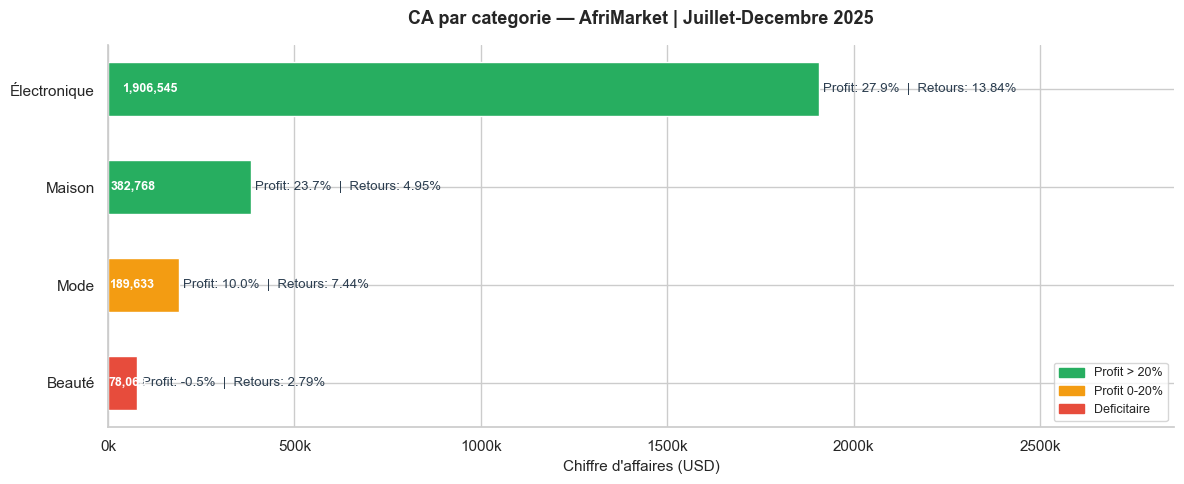

In [12]:
# ── Agregation par categorie ───────────────────────────────────────────────────
cat_g = df_clean.groupby('categorie').agg(
    CA          = ('chiffre_affaires', 'sum'),
    Marge       = ('marge_brute',      'sum'),
    Profit      = ('profit_net',       'sum'),
    Retours     = ('indicateur_retour','sum'),
    Annulations = ('indicateur_annulation','sum'),
    Nb_cmd      = ('id_commande',      'count')
).reset_index()
# Calcule CA, marge, profit et volumes par categorie en un seul groupby.

cat_g['Taux_retour_%']  = (cat_g['Retours']     / cat_g['Nb_cmd'] * 100).round(2)
cat_g['Taux_annul_%']   = (cat_g['Annulations'] / cat_g['Nb_cmd'] * 100).round(2)
cat_g['Part_CA_%']      = (cat_g['CA']           / cat_g['CA'].sum() * 100).round(1)
cat_g['Profit_%_CA']    = (cat_g['Profit']       / cat_g['CA']      * 100).round(1)
# Calcule les ratios cles — la Part_CA revele la concentration du risque.

cat_g = cat_g.sort_values('CA', ascending=False)
print('ANALYSE PAR CATEGORIE')
print(cat_g[['categorie','CA','Profit','Part_CA_%','Taux_retour_%','Profit_%_CA']].to_string(index=False))

# ── Visualisation VIZ 1 ───────────────────────────────────────────────────────
cat_viz = cat_g.sort_values('CA', ascending=True)  # Trie pour barh lisible
colors_cat = ['#e74c3c' if p < 0 else '#27ae60' if p > 20 else '#f39c12'
               for p in cat_viz['Profit_%_CA']]
# Code couleur : rouge=deficitaire, vert=profitable, orange=marge faible.

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(cat_viz['categorie'], cat_viz['CA'],
         color=colors_cat, edgecolor='white', height=0.55)

for i, (_, row) in enumerate(cat_viz.iterrows()):
    ax.text(row['CA'] + 12000, i,
            f"Profit: {row['Profit_%_CA']}%  |  Retours: {row['Taux_retour_%']}%",
            va='center', fontsize=9.5, color='#2c3e50')
    ax.text(row['CA'] * 0.02, i, f"{row['CA']:,.0f}",
            va='center', fontsize=9, fontweight='bold', color='white')
# Annote chaque barre avec le profit% et le taux de retour pour une lecture immediate.

ax.set_xlabel("Chiffre d'affaires (USD)", fontsize=11)
ax.set_title("CA par categorie — AfriMarket | Juillet-Decembre 2025",
              fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlim(0, cat_viz['CA'].max() * 1.50)
ax.spines[['top', 'right']].set_visible(False)
patches = [mpatches.Patch(color='#27ae60', label='Profit > 20%'),
           mpatches.Patch(color='#f39c12', label='Profit 0-20%'),
           mpatches.Patch(color='#e74c3c', label='Deficitaire')]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/viz1_ca_categorie.png', dpi=150, bbox_inches='tight')
# Sauvegarde en haute resolution dans le dossier outputs.
plt.show()

**Lecture :** Electronique domine avec 74,6% du CA mais affiche un taux de retour de 13,84% — 3x la norme e-commerce. La categorie Beaute est la seule deficitaire (-0.5% de profit net) : ses petits paniers ne couvrent pas les couts fixes de livraison.

---
## 7 — Analyse Geographique + Visualisation

ANALYSE PAR VILLE
      ville        CA    Profit  Part_CA_%  Taux_annul_%  Taux_retour_%
   Kinshasa 754363.75 189866.55      29.50          0.26           8.00
    Abidjan 500916.33 126527.34      19.60          0.00           8.71
     Douala 379324.37  95596.99      14.80         12.92           7.20
      Dakar 348707.40  86705.89      13.60          0.00           9.14
       Lomé 184253.82  46043.29       7.20          0.00           6.60
    Cotonou 159153.76  39504.35       6.20          0.00           7.92
 Libreville 124149.33  30781.17       4.90          0.00           9.42
Brazzaville 106145.54  26127.02       4.20          0.00           7.87


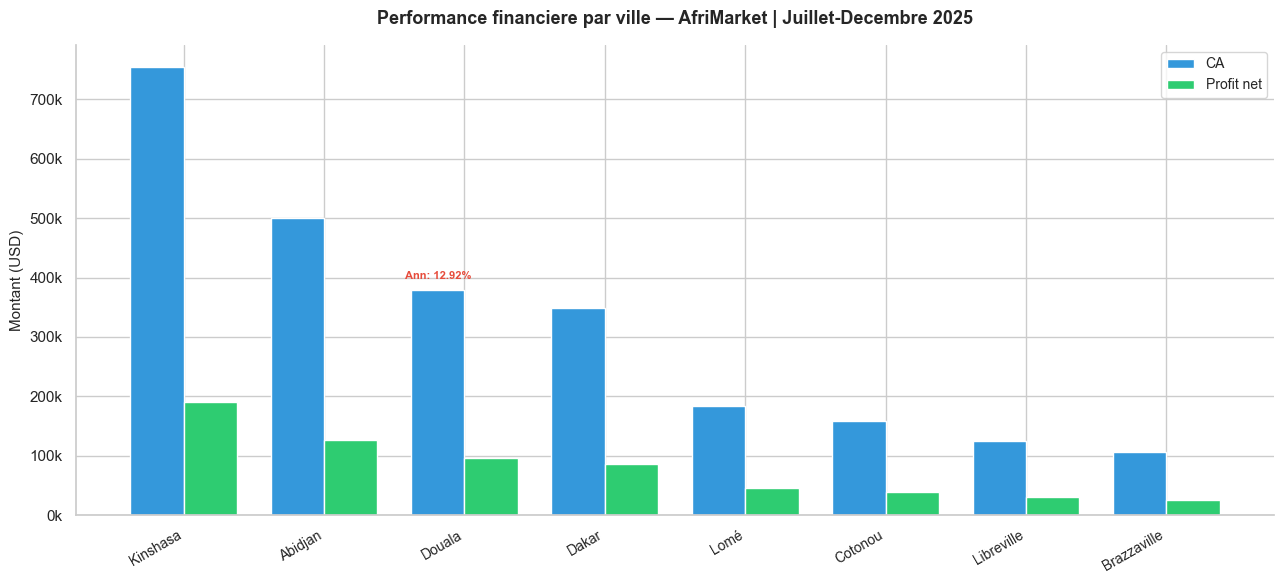

In [13]:
# ── Agregation par ville ───────────────────────────────────────────────────────
ville_g = df_clean.groupby('ville').agg(
    CA          = ('chiffre_affaires',     'sum'),
    Profit      = ('profit_net',           'sum'),
    Annulations = ('indicateur_annulation','sum'),
    Retours     = ('indicateur_retour',    'sum'),
    Nb_cmd      = ('id_commande',          'count')
).reset_index()
# Analyse complete par marche geographique incluant rentabilite et taux operationnels.

ville_g['Taux_annul_%']  = (ville_g['Annulations'] / ville_g['Nb_cmd'] * 100).round(2)
ville_g['Taux_retour_%'] = (ville_g['Retours']     / ville_g['Nb_cmd'] * 100).round(2)
ville_g['Part_CA_%']     = (ville_g['CA']           / ville_g['CA'].sum() * 100).round(1)
ville_g = ville_g.sort_values('CA', ascending=False)
# Trie par CA decroissant pour identifier les marches prioritaires.

print('ANALYSE PAR VILLE')
print(ville_g[['ville','CA','Profit','Part_CA_%','Taux_annul_%','Taux_retour_%']].to_string(index=False))

# ── Visualisation VIZ 2 ───────────────────────────────────────────────────────
x = np.arange(len(ville_g))
w = 0.38
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, ville_g['CA'],     w, label='CA',         color='#3498db', edgecolor='white')
ax.bar(x + w/2, ville_g['Profit'], w, label='Profit net', color='#2ecc71', edgecolor='white')
# Double barre CA vs Profit — revele l'ecart de rentabilite entre marches.

for i, (_, row) in enumerate(ville_g.iterrows()):
    if row['Taux_annul_%'] > 3:
        ax.annotate(f"Ann: {row['Taux_annul_%']}%",
                    xy=(i - w/2, row['CA']), xytext=(i - w/2, row['CA'] + 18000),
                    ha='center', fontsize=8, color='#e74c3c', fontweight='bold')
# Signale visuellement les anomalies d'annulation avec une fleche rouge.

ax.set_xticks(x)
ax.set_xticklabels(ville_g['ville'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Montant (USD)', fontsize=11)
ax.set_title('Performance financiere par ville — AfriMarket | Juillet-Decembre 2025',
              fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/viz2_villes.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture :** Kinshasa est le marche numero 1 (29,6% du CA). Douala presente une anomalie critique : taux d'annulation de 12,92% contre 0% dans toutes les autres villes — probleme logistique local a resoudre en priorite.

---
## 8 — Analyse Marketing + Visualisation

ANALYSE MARKETING
canal_marketing        CA     Cout    ROI  Part_CA_%  Part_Bud_%
          Email 545584.57  2349.15 231.20      21.30        3.40
     Google Ads 675026.43 13158.93  50.30      26.40       18.90
  Instagram Ads 966448.02 37637.07  24.70      37.80       54.20
    Influenceur 369955.29 16359.59  21.60      14.50       23.50


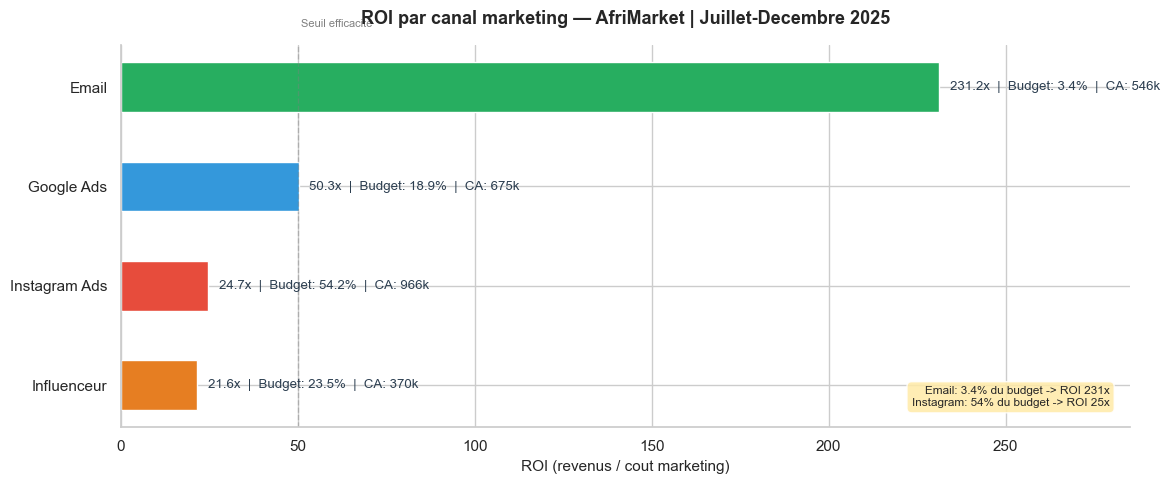

In [14]:
# ── Agregation par canal ───────────────────────────────────────────────────────
canal_g = df_clean.groupby('canal_marketing').agg(
    CA   = ('chiffre_affaires', 'sum'),
    Cout = ('cout_marketing',   'sum'),
    Nb   = ('id_commande',      'count')
).reset_index()
# Regroupe CA, cout et volume de commandes par canal pour comparer l'efficacite.

canal_g['ROI']         = ((canal_g['CA'] - canal_g['Cout']) / canal_g['Cout']).round(1)
canal_g['Part_CA_%']   = (canal_g['CA']   / canal_g['CA'].sum()   * 100).round(1)
canal_g['Part_Bud_%']  = (canal_g['Cout'] / canal_g['Cout'].sum() * 100).round(1)
# ROI = (Revenus - Cout) / Cout — formule standard de rentabilite marketing.
canal_g = canal_g.sort_values('ROI', ascending=False)

print('ANALYSE MARKETING')
print(canal_g[['canal_marketing','CA','Cout','ROI','Part_CA_%','Part_Bud_%']].to_string(index=False))

# ── Visualisation VIZ 3 ───────────────────────────────────────────────────────
color_map = {
    'Instagram Ads': '#e74c3c',  # Rouge : sur-finance / ROI faible
    'Influenceur':   '#e67e22',  # Orange : ROI moyen
    'Google Ads':    '#3498db',  # Bleu : bon ROI
    'Email':         '#27ae60',  # Vert : ROI exceptionnel / sous-finance
}
# Code couleur intuitif — le vert email vs le rouge Instagram raconte l'histoire immediatement.

canal_viz = canal_g.sort_values('ROI', ascending=True)
colors_v3 = [color_map.get(c, '#95a5a6') for c in canal_viz['canal_marketing']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(canal_viz['canal_marketing'], canal_viz['ROI'],
         color=colors_v3, edgecolor='white', height=0.5)

for i, (_, row) in enumerate(canal_viz.iterrows()):
    ax.text(row['ROI'] + 3, i,
            f"{row['ROI']}x  |  Budget: {row['Part_Bud_%']}%  |  CA: {row['CA']/1000:.0f}k",
            va='center', fontsize=9.5, color='#2c3e50')
# Annote chaque canal avec son ROI, sa part de budget et le CA genere.

ax.set_xlabel('ROI (revenus / cout marketing)', fontsize=11)
ax.set_title('ROI par canal marketing — AfriMarket | Juillet-Decembre 2025',
              fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 285)
ax.axvline(50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(51, 3.6, 'Seuil efficacite', fontsize=8, color='gray')
note = 'Email: 3.4% du budget -> ROI 231x\nInstagram: 54% du budget -> ROI 25x'
ax.text(0.98, 0.05, note, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', alpha=0.85))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/viz3_roi_marketing.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture :** Email genere un ROI de 231x avec seulement 3,4% du budget. Instagram absorbe 54% du budget pour un ROI de 25x — 9 fois moins rentable. C'est le principal levier de croissance immediat d'AfriMarket.

---
## 9 — Evolution Mensuelle + Visualisation

EVOLUTION MENSUELLE
 mois        CA    Profit  Croissance_%  Taux_retour_%
    7 402000.03 100163.81           NaN           8.06
    8 437452.11 110481.64          8.80           8.04
    9 408636.46 103032.48         -6.60           9.06
   10 435402.24 108783.56          6.60           8.04
   11 401106.70  99499.48         -7.90           8.60
   12 472416.75 119191.62         17.80           7.18


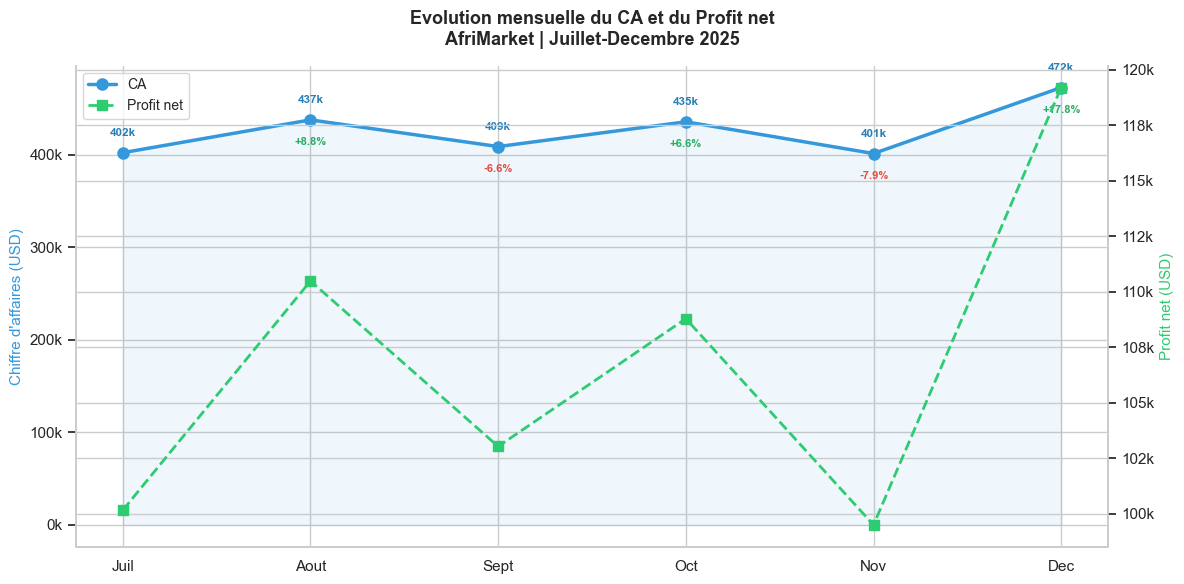

In [15]:
# ── Agregation mensuelle ───────────────────────────────────────────────────────
monthly = df_clean.groupby('mois').agg(
    CA      = ('chiffre_affaires', 'sum'),
    Profit  = ('profit_net',       'sum'),
    Nb_cmd  = ('id_commande',      'count'),
    Retours = ('indicateur_retour','sum')
).reset_index().sort_values('mois')
# Analyse temporelle sur 6 mois pour identifier les cycles de croissance.

monthly['Croissance_%']   = monthly['CA'].pct_change().mul(100).round(1)
monthly['Taux_retour_%']  = (monthly['Retours'] / monthly['Nb_cmd'] * 100).round(2)
# Variation mensuelle en % et taux de retour mensuel pour detecter les tendances.

mois_labels = ['Juil','Aout','Sept','Oct','Nov','Dec']
ca_v  = monthly['CA'].values
cr_v  = monthly['Croissance_%'].values
pr_v  = monthly['Profit'].values

print('EVOLUTION MENSUELLE')
print(monthly[['mois','CA','Profit','Croissance_%','Taux_retour_%']].to_string(index=False))

# ── Visualisation VIZ 4 ───────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(mois_labels, ca_v, marker='o', lw=2.5, ms=8,
         color='#3498db', label='CA', zorder=3)
ax1.fill_between(mois_labels, ca_v, alpha=0.08, color='#3498db')
ax2.plot(mois_labels, pr_v, marker='s', lw=2, ms=7,
         color='#2ecc71', linestyle='--', label='Profit net', zorder=3)
# Double axe : CA a gauche (echelle haute), Profit a droite (echelle basse).

for i in range(len(mois_labels)):
    ax1.annotate(f'{ca_v[i]/1000:.0f}k',
                 xy=(i, ca_v[i]), xytext=(0, 12),
                 textcoords='offset points', ha='center',
                 fontsize=8.5, fontweight='bold', color='#2980b9')
    if i > 0 and not np.isnan(cr_v[i]):
        col = '#27ae60' if cr_v[i] > 0 else '#e74c3c'
        ax1.annotate(f'{cr_v[i]:+.1f}%',
                     xy=(i, ca_v[i]), xytext=(0, -18),
                     textcoords='offset points', ha='center',
                     fontsize=8, color=col, fontweight='bold')
# Annote chaque point avec le CA en k et la variation mensuelle coloritee.

ax1.set_ylabel("Chiffre d'affaires (USD)", fontsize=11, color='#3498db')
ax2.set_ylabel('Profit net (USD)', fontsize=11, color='#2ecc71')
ax1.set_title('Evolution mensuelle du CA et du Profit net\nAfriMarket | Juillet-Decembre 2025',
               fontsize=13, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=10)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/viz4_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture :** Le CA suit un pattern en W avec des oscillations de ±7-9% entre mois. Decembre est exceptionnel (+17,8%). Les creux de Septembre et Novembre sont anticipes — une campagne Email preventive peut les lisser.

---
## 10 — Analyse Clients + Visualisation

Clients uniques    : 1747
Clients recurrents : 1293 (74.0%)
Pareto 20/80       : Top 20% clients = 64.1% du CA

SEGMENTATION CLIENTS
segment_client  Nb   CA_total  CA_moyen  Part_CA_%  Part_cli_%
        Fidèle 608 2010401.27   3306.58      78.60       34.80
       Nouveau 454  118198.16    260.35       4.60       26.00
      Régulier 685  428414.87    625.42      16.80       39.20

TOP 10 CLIENTS
id_client  clv_totale  nb_commandes_client segment_client
    C0157    11553.74                   26         Fidèle
    C0266    10673.23                   19         Fidèle
    C0120     9581.12                   29         Fidèle
    C0003     9473.08                   26         Fidèle
    C0051     9419.49                   17         Fidèle
    C0001     9162.97                   26         Fidèle
    C0379     8995.65                   25         Fidèle
    C0114     8941.72                   21         Fidèle
    C0067     8617.56                   20         Fidèle
    C0184     8549.

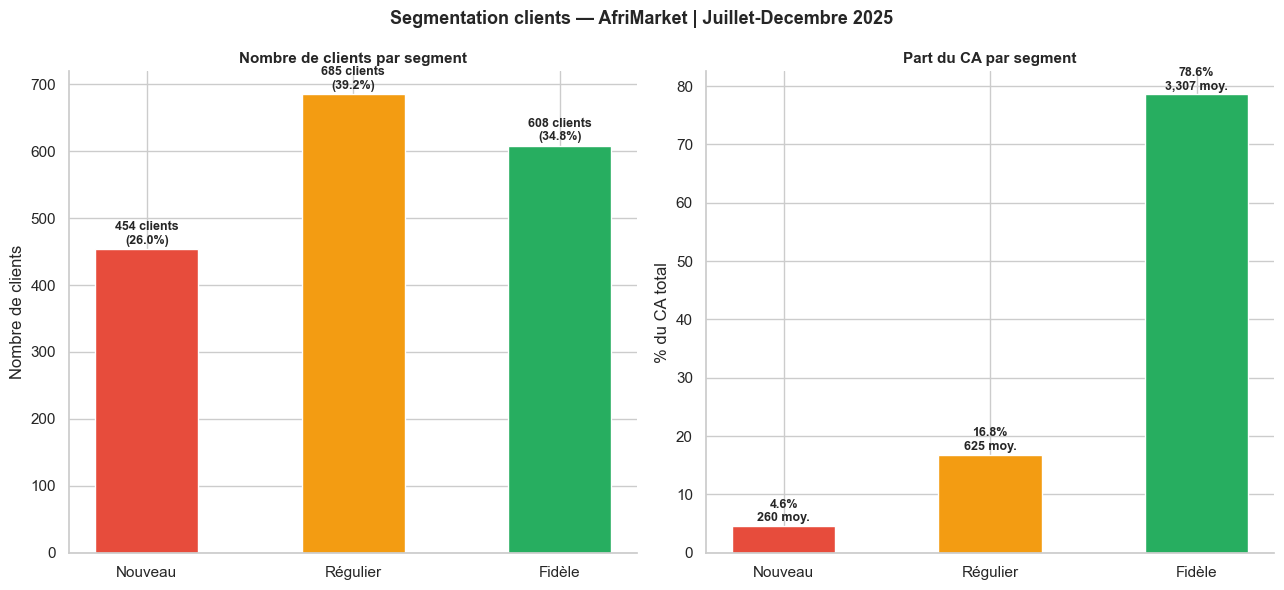

In [16]:
# ── Metriques clients ──────────────────────────────────────────────────────────
clients = df_clean.drop_duplicates('id_client')
# Une ligne par client unique pour les analyses de base.

n_clients  = len(clients)
n_recur    = (clients['nb_commandes_client'] > 1).sum()
pct_recur  = n_recur / n_clients * 100
# Taux de recurrence : proportion de clients ayant commande plus d'une fois.

n20        = int(n_clients * 0.20)
top20_ca   = clients.sort_values('clv_totale', ascending=False).head(n20)['clv_totale'].sum()
pareto_pct = top20_ca / clients['clv_totale'].sum() * 100
# Analyse Pareto : part du CA generee par les 20% de clients a plus haute valeur.

print(f'Clients uniques    : {n_clients}')
print(f'Clients recurrents : {n_recur} ({pct_recur:.1f}%)')
print(f'Pareto 20/80       : Top 20% clients = {pareto_pct:.1f}% du CA')

# ── Segmentation ──────────────────────────────────────────────────────────────
seg = clients.groupby('segment_client').agg(
    Nb       = ('id_client',   'count'),
    CA_total = ('clv_totale',  'sum'),
    CA_moyen = ('clv_totale',  'mean')
).reset_index()
seg['Part_CA_%'] = (seg['CA_total'] / seg['CA_total'].sum() * 100).round(1)
seg['Part_cli_%'] = (seg['Nb'] / n_clients * 100).round(1)
print('\nSEGMENTATION CLIENTS')
print(seg.to_string(index=False))

# ── Top 10 clients ─────────────────────────────────────────────────────────────
top10 = clients.sort_values('clv_totale', ascending=False).head(10)[
    ['id_client','clv_totale','nb_commandes_client','segment_client']
]
print('\nTOP 10 CLIENTS')
print(top10.to_string(index=False))

# ── Visualisation VIZ 5 ───────────────────────────────────────────────────────
ordre = ['Nouveau', 'Régulier', 'Fidèle']
seg_viz = seg.set_index('segment_client').reindex(ordre).reset_index()
colors_seg = ['#e74c3c', '#f39c12', '#27ae60']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.bar(seg_viz['segment_client'], seg_viz['Nb'],
         color=colors_seg, edgecolor='white', width=0.5)
for i, row in seg_viz.iterrows():
    ax1.text(i, row['Nb'] + 8,
             f"{int(row['Nb'])} clients\n({row['Part_cli_%']:.1f}%)",
             ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Nombre de clients par segment', fontsize=11, fontweight='bold')
ax1.set_ylabel('Nombre de clients')
ax1.spines[['top','right']].set_visible(False)

ax2.bar(seg_viz['segment_client'], seg_viz['Part_CA_%'],
         color=colors_seg, edgecolor='white', width=0.5)
for i, row in seg_viz.iterrows():
    ax2.text(i, row['Part_CA_%'] + 0.8,
             f"{row['Part_CA_%']}%\n{row['CA_moyen']:,.0f} moy.",
             ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Part du CA par segment', fontsize=11, fontweight='bold')
ax2.set_ylabel('% du CA total')
ax2.spines[['top','right']].set_visible(False)

fig.suptitle('Segmentation clients — AfriMarket | Juillet-Decembre 2025',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/viz5_clients.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture :** 608 clients Fideles (34,8%) generent 78,5% du CA. Un client Fidele vaut 12,7x un client Nouveau. Les 685 clients Reguliers sont la zone de conversion prioritaire — les amener a 4+ commandes multiplie leur valeur par 5.

---
## 11 — Heatmap Taux de Retour par Categorie x Ville

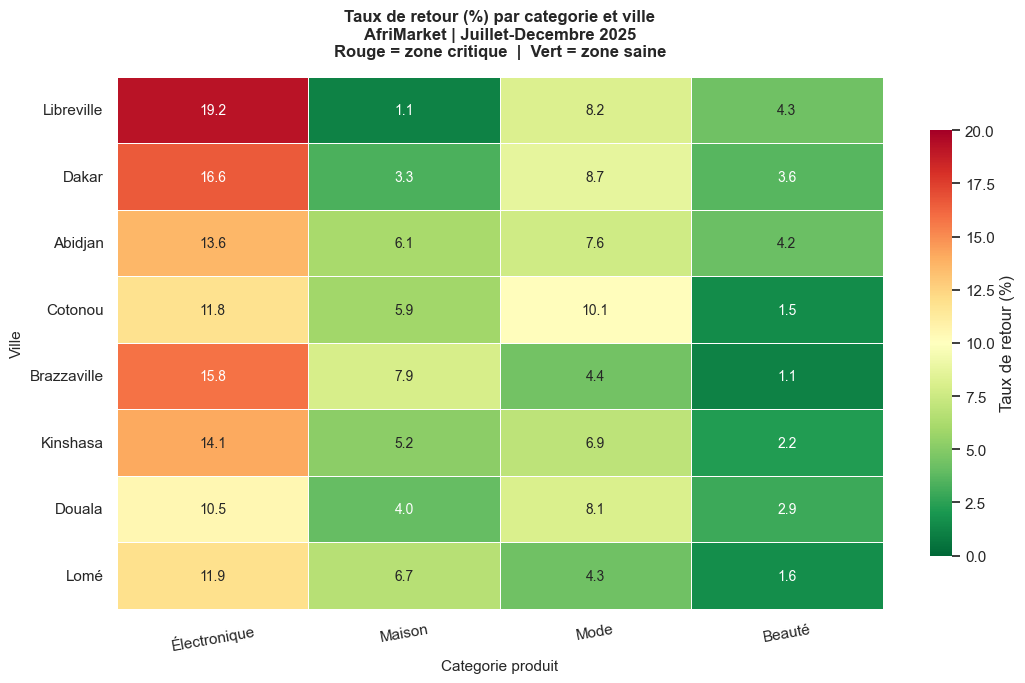

In [17]:
# ── Calcul taux de retour croise ──────────────────────────────────────────────
hm = df_clean.groupby(['ville', 'categorie']).agg(
    Retours = ('indicateur_retour', 'sum'),
    Total   = ('id_commande',       'count')
).reset_index()
hm['Taux_%'] = (hm['Retours'] / hm['Total'] * 100).round(1)
# Calcule le taux de retour pour chaque combinaison ville x categorie.

pivot = hm.pivot(index='ville', columns='categorie', values='Taux_%')
# Transforme en matrice 2D pour la heatmap — chaque cellule est un taux de retour.

cat_order   = ['Électronique', 'Maison', 'Mode', 'Beauté']
final_cats  = [c for c in cat_order if c in pivot.columns]
ville_order = sorted(pivot.index, key=lambda v: pivot.loc[v].sum(), reverse=True)
pivot = pivot.reindex(index=ville_order, columns=final_cats)
# Ordonne villes (par CA total) et categories (par importance strategique).

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Taux de retour (%)', 'shrink': 0.8},
    vmin=0, vmax=20, ax=ax, annot_kws={'size': 10}
)
# RdYlGn_r : rouge=taux eleve (mauvais), vert=taux faible (bon) — lecture intuitive.

ax.set_title(
    'Taux de retour (%) par categorie et ville\n'
    'AfriMarket | Juillet-Decembre 2025\n'
    'Rouge = zone critique  |  Vert = zone saine',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Categorie produit', fontsize=11)
ax.set_ylabel('Ville', fontsize=11)
ax.tick_params(axis='x', rotation=10)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('outputs/viz6_heatmap_retours.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture :** La heatmap revele que le probleme de retours est specifiquement concentre sur Electronique dans plusieurs villes, avec Libreville et Dakar comme zones les plus critiques. Beaute affiche les taux les plus bas — coherent avec ses faibles volumes.


## 12 — Resume Executif

### AfriMarket | Analyse strategique | Juillet – Decembre 2025


**Situation generale**

Sur 6 mois d'activite, AfriMarket a genere **2 557 014 USD de CA** avec un profit net de **641 153 USD** (25,1% de marge nette). La base clientele compte **1 747 clients** dont **74% sont recurrents** — un indicateur de fidelite remarquable, bien au-dessus de la moyenne sectorielle de 20-30%.

**Ce qui fonctionne bien**

- **Email Marketing** : ROI de 231x avec seulement 3,4% du budget — meilleur actif marketing
- **Kinshasa** : marche numero 1 a 29,6% du CA, taux d'annulation quasi nul (0,26%)
- **Fidelite client** : 608 clients Fideles generent 78,5% du CA total
- **Marge nette** : 25,1% — solide pour un e-commerce panafricain


**3 signaux d'alarme immediats**

1. **Electronique — Taux de retour 13,84%** (norme : 3-5%)
   → ~286 000 USD de CA perdu en retours sur 6 mois
   → Categorie qui represente 74,6% du CA : risque systémique

2. **Douala — Taux d'annulation 12,92%** (vs 0% dans 6 autres villes)
   → Probleme logistique local identifie et localise
   → CA perdu + couts marketing engages sans revenu

3. **Beaute — Seule categorie deficitaire** (profit net : -380 USD)
   → Structure de couts incompatible avec le niveau de prix actuel
   → 1 758 commandes traitees a perte

---

**Opportunite sous-exploitee**

Email Marketing recoit 2 349 USD de budget (3,4%) pour generer 545 585 USD de CA (ROI 231x). Instagram recoit 37 637 USD (54%) pour un ROI de 25x. La realocation de budget vers Email est l'action a ROI le plus eleve et le plus rapide a executer.

---

**Projection 12 mois**

En appliquant les 5 recommandations ci-dessous, AfriMarket peut viser **+600 000 a +800 000 USD de CA additionnel** sur les 6 prochains mois sans acquisition massive de nouveaux clients.

---
## 13 — 5 Recommandations Strategiques

---

### R1 — Auditer et corriger les retours Electronique *(0-2 mois)*

**Constat :** Taux de retour Electronique a 13,84% — 3x la norme sectorielle. 491 commandes retournees = ~286 000 USD de CA perdu sur 6 mois.

**Action :** Analyser les 491 retours par produit, ville et motif. Ameliorer les fiches produits (photos 360°, specifications techniques). Clarifier la politique de retour. Auditer les fournisseurs.

**KPI de succes :** Taux retour Electronique < 8% en 3 mois

**Risque si inaction :** A 13,84%, AfriMarket perd 286 000 USD de CA tous les 6 mois sur sa categorie principale.

---

### R2 — Resoudre la logistique Douala *(0-1 mois — URGENT)*

**Constat :** Taux d'annulation Douala = 12,92% vs 0% dans toutes les autres villes. Probleme isole, localise, donc corrigible rapidement.

**Action :** Audit immediat du partenaire livraison local a Douala. Renégociation ou changement de prestataire. Compensation clients affectes.

**KPI de succes :** Taux annulation Douala < 3% en 30 jours

**Risque si inaction :** Chaque commande annulee = cout marketing engage sans revenu + risque de perte definitive du client.

---

### R3 — Multiplier le budget Email par 4 *(0-3 mois — Quick Win)*

**Constat :** Email ROI = 231x avec 3,4% du budget. Instagram ROI = 25x avec 54% du budget. Ecart de rentabilite : 9x.

**Action :** Passer le budget Email de 2 349 a 9 000 USD. Creer 3 sequences automatisees : (1) relance clients Reguliers inactifs 45j, (2) offre fidelite a la 3e commande, (3) panier abandonne.

**KPI de succes :** CA Email > 25% du CA total | ROI Email > 80x

**Projection conservatrice :** ROI 80x sur 9 000 de budget = 720 000 USD de CA additionnel.

---

### R4 — Panier minimum Beaute ou suspension *(1-2 mois)*

**Constat :** Beaute est deficitaire (-380 USD de profit net). Panier moyen = 44 USD — trop bas pour absorber les couts fixes de livraison (~6 USD) et marketing (~5,8 USD).

**Action :** Option A : imposer un panier minimum de 3 500 USD + bundling "3 produits = livraison offerte". Option B : suspendre Beaute et reallouer les ressources vers Maison (profit 23,7%).

**KPI de succes :** Profit net Beaute > 0 sous 60 jours

---

### R5 — Programme de conversion Regulier → Fidele *(2-5 mois)*

**Constat :** 685 clients Reguliers a 625 USD de CA moyen vs 608 clients Fideles a 3 307 USD. Un client Fidele vaut 5,3x un client Regulier.

**Action :** Offre declenchee automatiquement a la 3e commande (remise 10% + livraison gratuite). Sequence Email de conversion sur 4 semaines. Programme de points de fidelite simple.

**KPI de succes :** 200 clients Reguliers convertis en Fideles en 6 mois

**Impact calcule :** 200 conversions x (3 307 - 625) = **+536 400 USD de CA additionnel**.

---

### Matrice de priorisation

| Priorite | Recommandation | Type | Horizon | ROI estime |
|---|---|---|---|---|
| P1 | Logistique Douala | Quick Win | 0-1 mois | >300% |
| P2 | Budget Email x4 | Quick Win | 0-3 mois | 80x |
| P3 | Retours Electronique | Projet majeur | 0-2 mois | 1,9M USD |
| P4 | Programme fidelite | Projet majeur | 2-5 mois | 3,5x |
| P5 | Panier minimum Beaute | Quick Win | 1-2 mois | Profit > 0 |

---
## 14 — Conclusion Business

AfriMarket dispose d'un modele economique solide : **25,1% de marge nette**, 74% de clients recurrents, et un actif Email Marketing au ROI exceptionnel (231x). Ce ne sont pas des signaux d'une entreprise fragile — c'est une entreprise qui perd de la valeur sur des points precis et corrigeables.

**Les trois decisions a prendre cette semaine :**

1. **Autoriser l'audit logistique Douala** — intervention rapide, impact immediat, cout faible
2. **Valider la realocation budget Email** — de 3,4% a 15% du budget marketing
3. **Commander un audit qualite Electronique** — analyser les 491 retours pour identifier la cause racine

Ces trois actions seules peuvent generer **+300 000 a +500 000 USD de CA additionnel** en 90 jours, sans recruter un seul nouveau client.

La croissance d'AfriMarket ne viendra pas de l'acquisition — elle viendra de l'optimisation de ce qui fonctionne deja.

*Analyse realisee par : DAVID SOUWAN | Data Analyst | 2025*  
*Outils : Python (pandas, numpy, matplotlib, seaborn)*